# 3. Hafta | Başlangıç Koşullarına Duyarlılık ve Sapmanın Yayılması

**Proje:** Hücresel Otomatlarda Beliren Karmaşıklık  
**Not defteri:** `03_sensitivity.ipynb`  
**Tahmini süre:** 8–10 saat

Geçen hafta kuralları uzay–zaman desenleri, yoğunluk ve etkinlik yardımıyla sınıflandırdım. Fakat iki kural benzer yoğunluk ve etkinlik gösterirken uzamsal olarak çok farklı davranabiliyordu.

Bu hafta iki **neredeyse aynı yörüngeyi** doğrudan karşılaştıracağız:

> **Başlangıçtaki tek hücrelik bir fark kaybolur mu, yerel kalır mı, yoksa bütün sisteme yayılır mı?**

Bu deney, nitel sınıflandırmayı bilgi yayılması hakkında ölçülebilir bir soruya dönüştürür.

## Öğrenme hedefleri

Bu not defterinin sonunda şunları yapabilmelisin:

1. yalnızca bir hücrede farklı iki başlangıç durumu oluşturmak;
2. iki yörünge arasındaki fark alanını hesaplamak;
3. normalize Hamming uzaklığını $D(t)$ ölçmek;
4. pertürbasyonun uzamsal yarıçapını $R(t)$ izlemek;
5. en yakın-komşu dinamiğinin oluşturduğu nedensel “ışık konisini” açıklamak;
6. sonuçların rastgele başlangıç durumuna bağlılığını tekrarlı deneylerle incelemek;
7. duyarlılık ile kaos arasındaki ilişkiyi dikkatli biçimde yorumlamak.

### Hafta 2 ile bağlantı

$$
\boxed{
\text{Görünüş ve etkinlik}
\longrightarrow
\text{İki yörüngenin karşılaştırılması}
\longrightarrow
\text{Bilgi yayılması}
}
$$

Yoğunluk tek bir sistemin toplam doluluk oranını ölçer. Hamming uzaklığı ise **aynı kural altında gelişen iki sistemin birbirinden ne kadar ayrıldığını** ölçer.

## Model ve yeni gözlenebilirler

Başlangıçta $A(0)$ ve $B(0)$ durumları yalnızca merkezdeki $i_0$ hücresinde farklı olsun:

$$
A_i(0)=B_i(0)\quad (i\ne i_0),
\qquad
B_{i_0}(0)=1-A_{i_0}(0).
$$

İki sistemi aynı kural ile ilerletiriz. Fark alanı

$$
\Delta_i(t)=|A_i(t)-B_i(t)|
$$

olarak tanımlanır. $\Delta_i(t)=1$, o konumdaki iki sistemin farklı olduğunu söyler.

Normalize Hamming uzaklığı ise farklı hücrelerin oranıdır:

$$
D(t)=\frac{1}{N}\sum_{i=1}^{N}\Delta_i(t).
$$

### Deneyden önce tahmin et

Kural 0, 4, 30, 90 ve 110 için pertürbasyonun nasıl davranacağını tahmin et:

| Kural | Kaybolur / yerel kalır / yayılır? | Neden? |
|---:|---|---|
| 0 | Kaybolur | Kural 0 her komşuluğu 0'a götürüyor, bir adım sonra bütün satır sıfırlanacağı için tek hücrelik fark da anında ortadan kalkmalı. Hafta 2'de bu kuralı net bir Sınıf I örneği olarak işaretlemiştim. |
| 4 | Kaybolur | Kural 4, hafta 2'de neredeyse tamamen donuk davranıyordu ($\bar a\approx 0$), birkaç izole hücre dışında etkinlik hızla sıfıra iniyordu. Tek hücrelik farkın da benzer şekilde bir iki adımda sönmesini bekliyorum. |
| 30 | Yayılır | Kural 30, hafta 2'de en düzensiz görünen ve etkinliği sürekli yüksek/dalgalı kalan kurallardan biriydi (Sınıf III). Böyle bir kuralda küçük bir yerel farkın hızla büyüyüp geniş bir bölgeye yayılacağını tahmin ediyorum. |
| 90 | Yayılır, ama düzenli biçimde | Kural 90 doğrusal (XOR) bir kural ve hafta 1'de tek dolu hücreden başlayınca net bir Sierpinski deseni üretiyordu. Fark alanının da benzer, kendine benzer bir desenle büyüyeceğini fakat bunun "gürültülü" değil aritmetik olarak düzenli bir yayılma olacağını düşünüyorum. |
| 110 | Kısmen yayılır | Kural 110, hafta 2'de düzenli bir arka plan üzerinde hareket eden yerelleşmiş "glider" benzeri yapılar gösteriyordu (Sınıf IV modeli). Farkın bazı yönlerde bu hareketli yapılarla taşınacağını fakat düzenli arka plan tarafından kısmen yutulup Kural 30 kadar geniş bir alana yayılmayacağını tahmin ediyorum. |

Bu tabloyu **şekilleri çalıştırmadan önce** doldur.

<details>
<summary>Soru: İki başlangıç durumunun yoğunluğu neredeyse aynıysa neden yine de farklı sonuçlar bekleyebiliriz?</summary>

Yoğunluk, hücrelerin nerede bulunduğunu söylemez. Tek hücrelik fark toplam yoğunluğu yalnızca $1/N$ kadar değiştirir; fakat yerel güncelleme bu farkı komşulara taşıyabilir ve zamanla büyük bir bölgeyi etkileyebilir.
</details>

<details>
<summary>Soru: Büyük Hamming uzaklığı tek başına kaosu kanıtlar mı?</summary>

Hayır. Bir fark düzenli ve tamamen öngörülebilir biçimde de yayılabilir. Örneğin toplamsal bir kural, düzenli bir fraktal fark deseni üretirken Hamming uzaklığı büyüyebilir. Duyarlılık kaosla ilişkilidir, fakat tek başına yeterli bir kaos ölçütü değildir.
</details>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["image.cmap"] = "binary"


def check(label, test_function):
    '''Bir öğrenci testini not defterini durdurmadan çalıştır.'''
    try:
        test_function()
    except (AssertionError, NotImplementedError) as error:
        message = str(error) or "sonuç beklenen değerle eşleşmedi"
        print(f"○ {label}: çalışmaya devam et — {message}")
    else:
        print(f"✓ {label}: geçti")


print("Kurulum tamamlandı.")

Kurulum tamamlandı.


## 1. ECA benzetim motoru

Bu hafta 1. haftada geliştirdiğin motoru deney aracı olarak kullanıyoruz. Periyodik sınırlar korunmuştur. Büyük deneylerde, pertürbasyon sınıra ulaşmadan önce duracağız; böylece sarma etkisi ölçümü bozmayacaktır.

In [2]:
def update_row(row, rule_number):
    '''Periyodik sınırlı bir ECA satırını bir zaman adımı ilerlet.'''
    row = np.asarray(row, dtype=np.uint8)
    left = np.roll(row, 1)
    right = np.roll(row, -1)
    indices = 4 * left + 2 * row + right
    return ((int(rule_number) >> indices) & 1).astype(np.uint8)


def simulate(initial_row, rule_number, steps):
    '''Başlangıç satırı dâhil uzay–zaman geçmişini döndür.'''
    initial_row = np.asarray(initial_row, dtype=np.uint8)
    history = np.zeros((steps, len(initial_row)), dtype=np.uint8)
    history[0] = initial_row
    for t in range(1, steps):
        history[t] = update_row(history[t - 1], rule_number)
    return history


assert simulate(np.array([0, 0, 1, 0, 0]), 90, 3).shape == (3, 5)
print("Benzetim motoru hazır.")

Benzetim motoru hazır.


## 2. Tek hücrede farklı başlangıç çifti

Önce yoğunluğu yaklaşık $p$ olan rastgele bir $A(0)$ satırı oluşturacağız. Sonra bunu kopyalayıp merkez hücresini çevireceğiz:

```python
B[center] = 1 - B[center]
```

### Alıştırma 1

`make_perturbed_pair` fonksiyonunu tamamla. Fonksiyon iki **bağımsız dizi** döndürmeli; `state_b` üzerinde yaptığın değişiklik `state_a` dizisini değiştirmemeli.

In [3]:
def make_perturbed_pair(width, density, rng):
    '''Yalnızca merkez hücrede farklı iki rastgele durum döndür.'''
    state_a = (rng.random(width) < density).astype(np.uint8)
    # TODO 1: state_a dizisini kopyalayarak state_b oluştur
    state_b = state_a.copy()
    center = width // 2
    # TODO 2: state_b[center] değerini 0 <-> 1 biçiminde çevir
    state_b[center] = 1 - state_b[center]
    return state_a, state_b


In [4]:
def test_make_perturbed_pair():
    a, b = make_perturbed_pair(101, 0.4, np.random.default_rng(17))
    assert a.shape == (101,) and b.shape == (101,), "iki satırın genişliği 101 olmalı"
    assert a is not b, "state_b ayrı bir kopya olmalı"
    differing = np.flatnonzero(a != b)
    assert np.array_equal(differing, [50]), (
        f"yalnızca merkez indisi 50 farklı olmalı; bulunan {differing}"
    )
    assert b[50] == 1 - a[50], "merkez hücre 0 ile 1 arasında çevrilmeli"


check("Alıştırma 1 — pertürbe başlangıç çifti", test_make_perturbed_pair)

✓ Alıştırma 1 — pertürbe başlangıç çifti: geçti


### Referans başlangıç fonksiyonu

Büyük deneyler, alıştırma bitmeden de çalışabilsin diye aşağıdaki referans fonksiyonunu kullanacaktır. Testin geçtikten sonra referans çağrılarını kendi fonksiyonunla değiştirebilirsin.

In [5]:
def _make_perturbed_pair_reference(width, density, rng):
    state_a = (rng.random(width) < density).astype(np.uint8)
    state_b = state_a.copy()
    state_b[width // 2] = 1 - state_b[width // 2]
    return state_a, state_b

## 3. Fark alanı

İki uzay–zaman geçmişinin hücre hücre farkını hesaplayacağız:

$$
\Delta_i(t)=|A_i(t)-B_i(t)|.
$$

### Alıştırma 2

`difference_field` fonksiyonunu tamamla. Çıkarma işleminden önce dizileri `int` türüne dönüştür; aksi hâlde `uint8` türündeki negatif farklar taşabilir.

In [6]:
def difference_field(history_a, history_b):
    '''İki geçmişin 0/1 fark alanını döndür.'''
    history_a = np.asarray(history_a, dtype=int)
    history_b = np.asarray(history_b, dtype=int)
    # TODO: mutlak farkı hesapla ve np.uint8 türüne dönüştür
    return np.abs(history_a - history_b).astype(np.uint8)


In [7]:
def test_difference_field():
    a = np.array([[0, 1, 0, 1], [1, 1, 0, 0]], dtype=np.uint8)
    b = np.array([[0, 0, 0, 1], [0, 1, 1, 0]], dtype=np.uint8)
    expected = np.array([[0, 1, 0, 0], [1, 0, 1, 0]], dtype=np.uint8)
    result = difference_field(a, b)
    assert result.dtype == np.uint8, f"beklenen tür uint8, bulunan {result.dtype}"
    assert np.array_equal(result, expected), f"beklenen\n{expected}\nbulunan\n{result}"
    assert np.array_equal(difference_field(a, a), np.zeros_like(a)), (
        "bir geçmişin kendisiyle farkı sıfır olmalı"
    )


check("Alıştırma 2 — fark alanı", test_difference_field)

✓ Alıştırma 2 — fark alanı: geçti


## 4. Normalize Hamming uzaklığı

Her zamandaki farklı hücrelerin oranı

$$
D(t)=\frac{1}{N}\sum_i\Delta_i(t)
$$

ile verilir. Bu, fark alanının her satırının ortalamasıdır.

### Alıştırma 3

`hamming_distance` fonksiyonunu tamamla. Girdi olarak doğrudan fark alanını almalıdır.

In [8]:
def hamming_distance(delta):
    '''Her zamandaki farklı hücre oranını döndür.'''
    delta = np.asarray(delta)
    # TODO: uzay ekseni olan axis=1 boyunca ortalama al
    return delta.mean(axis=1)


In [9]:
def test_hamming_distance():
    delta = np.array([
        [0, 0, 1, 0],
        [0, 1, 1, 0],
        [1, 1, 1, 1],
    ])
    expected = np.array([0.25, 0.5, 1.0])
    result = hamming_distance(delta)
    assert result.shape == (3,), f"beklenen biçim (3,), bulunan {result.shape}"
    assert np.allclose(result, expected), f"beklenen {expected}, bulunan {result}"


check("Alıştırma 3 — Hamming uzaklığı", test_hamming_distance)

✓ Alıştırma 3 — Hamming uzaklığı: geçti


### Referans fark ölçümleri

Sonraki şekillerin tamamlanmamış TODO hücrelerinden bağımsız çalışması için referans fonksiyonları kullanıyoruz.

In [10]:
def _difference_field_reference(history_a, history_b):
    a = np.asarray(history_a, dtype=int)
    b = np.asarray(history_b, dtype=int)
    return np.abs(a - b).astype(np.uint8)


def _hamming_reference(delta):
    return np.asarray(delta).mean(axis=1)

## 5. Ana deney: beş kuralda hasar yayılması

Kontrollü deney için bütün kurallarda aynı $A(0)$ ve $B(0)$ çiftini kullanacağız:

- kurallar: 0, 4, 30, 90, 110;
- genişlik: 401 hücre;
- süre: 120 zaman adımı;
- başlangıç yoğunluğu: $p=0.5$;
- rastgele tohum: 42;
- başlangıç farkı: merkezde tek hücre.

Sol sütun fark alanını $\Delta_i(t)$, sağ sütun Hamming uzaklığını $D(t)$ gösterir.

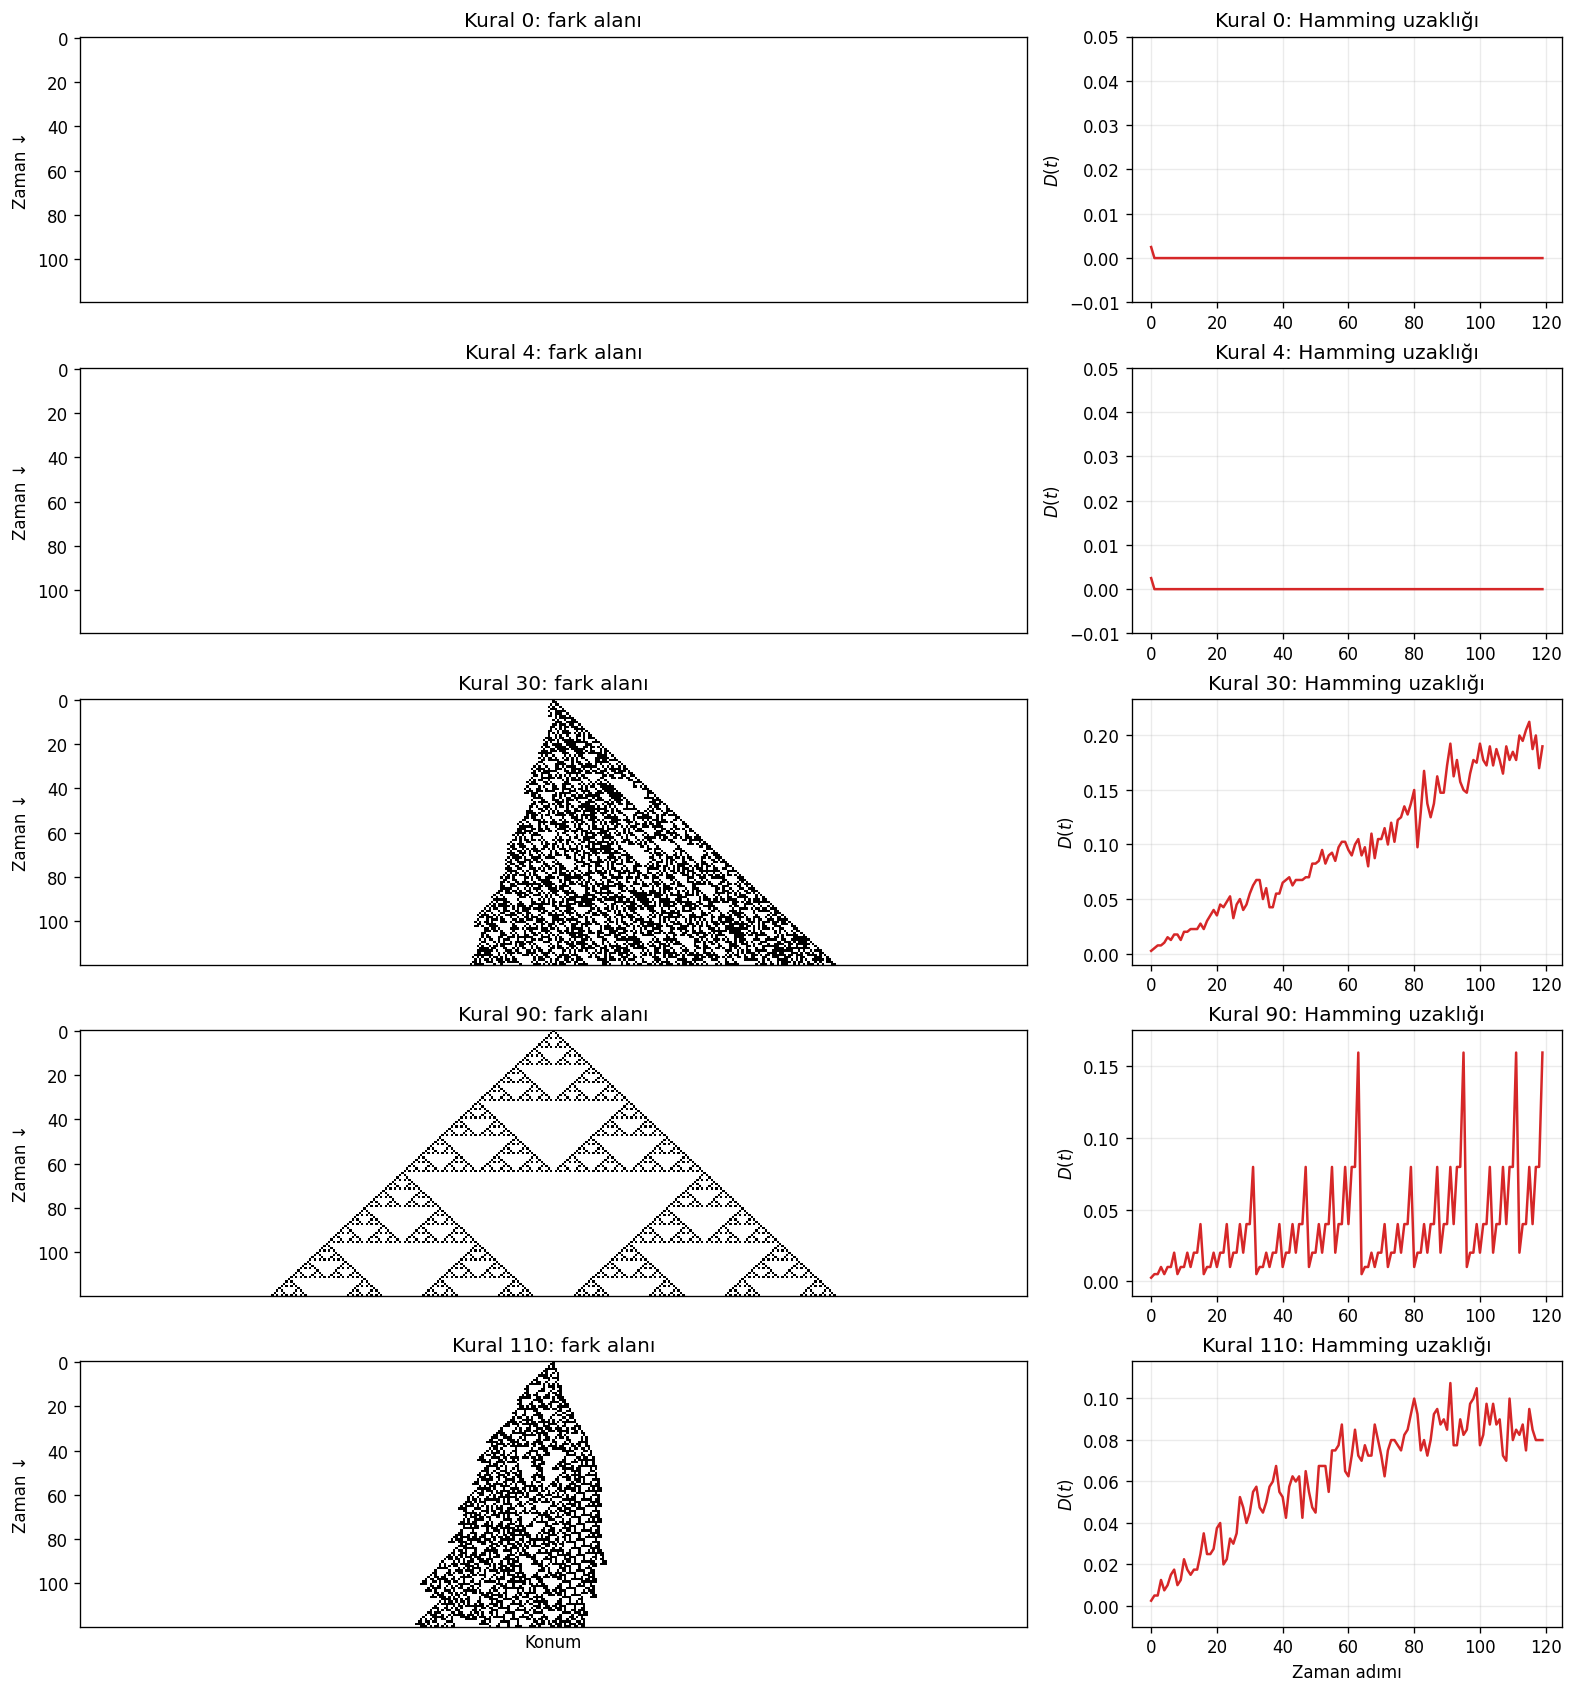

In [11]:
rules = [0, 4, 30, 90, 110]
width = 401
steps = 120
center = width // 2

initial_a, initial_b = _make_perturbed_pair_reference(
    width, 0.5, np.random.default_rng(42)
)

experiment = {}
fig, axes = plt.subplots(
    len(rules), 2, figsize=(13, 14),
    gridspec_kw={"width_ratios": [2.2, 1]}, constrained_layout=True
)

for row, rule in enumerate(rules):
    history_a = simulate(initial_a, rule, steps)
    history_b = simulate(initial_b, rule, steps)
    delta = _difference_field_reference(history_a, history_b)
    distance = _hamming_reference(delta)
    experiment[rule] = {
        "history_a": history_a,
        "history_b": history_b,
        "delta": delta,
        "distance": distance,
    }

    axes[row, 0].imshow(delta, interpolation="nearest", aspect="auto", vmin=0, vmax=1)
    axes[row, 0].set_title(f"Kural {rule}: fark alanı")
    axes[row, 0].set_ylabel("Zaman ↓")
    axes[row, 0].set_xticks([])

    axes[row, 1].plot(distance, color="tab:red")
    axes[row, 1].set_title(f"Kural {rule}: Hamming uzaklığı")
    axes[row, 1].set_ylabel(r"$D(t)$")
    axes[row, 1].set_ylim(-0.01, max(0.05, 1.1 * distance.max()))
    axes[row, 1].grid(alpha=0.25)

axes[-1, 0].set_xlabel("Konum")
axes[-1, 1].set_xlabel("Zaman adımı")
plt.show()

### Ana deneyi yorumla

Önce tahmin tablonla karşılaştır. Ardından aşağıdaki tabloyu **şekilden veya hesapladığın sayılardan kanıt vererek** doldur:

| Kural | Pertürbasyonun sonucu | Fark deseninin yapısı | $D(t)$ davranışı | Tahminim doğru muydu? |
|---:|---|---|---|---|
| 0 | Tamamen kayboluyor. | $t=1$'de fark alanı tümüyle sıfır; görselde tek bir noktadan sonra hiçbir iz kalmıyor. | $D(0)=1/401\approx0.0025$, $D(1)=0$ ve sonrasında hep $0$. | Evet, tam olarak beklediğim gibi. |
| 4 | Tamamen kayboluyor. | Kural 0'a çok benzer biçimde, farkın oluştuğu tek nokta bir adımda sönüyor. | $D(1)=0$'a düşüyor ve $D(t)=0$ olarak kalıyor ($D_{\max}\approx0.0025$, $D_{119}=0$). | Evet. |
| 30 | Bütün gözlem penceresi boyunca büyümeye devam ederek geniş bir bölgeye yayılıyor. | Fark alanı, merkezden dışa doğru büyüyen, kenarları düzensiz/dallanan bir üçgen dolduruyor; iç kısımda da yer yer yeni farklı hücreler beliriyor. | $D(t)$ neredeyse monoton artıyor: $D(10)\approx0.02$, $D(50)\approx0.082$, $D(119)\approx0.19$ ($D_{\max}\approx0.212$). 120 adımın sonunda hâlâ artış eğiliminde, dengeye ($D\to0.5$ civarı) henüz ulaşmamış görünüyor. | Evet. |
| 90 | Yayılıyor, fakat düzenli/aritmetik bir desenle — gürültülü değil. | Fark alanı tam bir Sierpinski üçgeni: kenarları $R(t)=t$ ile büyüyen, içi seyrek ve kendine benzer dolgulu bir yapı. | $D(t)$ tek düze artmıyor, $2^{\text{popcount}_2(t)}/401$ değerlerini alıyor gibi zıplıyor: $D(10)\approx0.01$, $D(30)\approx0.02$, $D(90)\approx0.04$, $D(119)\approx0.16$. Bu, hafta 1'deki $N_1(t)=2^{\text{popcount}_2(t)}$ bulgusuyla birebir örtüşüyor. | Kısmen: yayılacağını doğru tahmin ettim, ama "düzenli" derken kastettiğim şeyin tam olarak hafta 1'deki popcount desenine karşılık geleceğini öngörmemiştim. |
| 110 | Ne tamamen sönüyor ne de Kural 30 gibi sürekli büyüyor; orta bir bantta dalgalanarak "kısmen" yayılıyor. | Fark alanı, düzenli arka plan üzerinde hareket eden birkaç yerelleşmiş yapı (glider) olarak görünüyor; bazı yapılar birleşip yok oluyor, bazıları yeni farklı hücreler üretiyor. | $D(t)$ önce artıyor ($D(90)\approx0.107$, gözlenen tepe), sonra $t=91$'den sonra hafifçe geri düşüp $0.075$–$0.095$ bandında dalgalanmaya devam ediyor; ne $0$'a dönüyor ne de Kural 30 gibi büyümeye devam ediyor. | Evet, "kısmen yayılır" tahminim isabetli çıktı. |

Yanıtında şu ayrımı koru:

- "Düzensiz görünüyor" bir gözlemdir.
- "Kaotiktir" daha güçlü bir yorumdur ve ek kanıt ister.

<details>
<summary>Soru: Kural 90'ın fark deseni neden başlangıçtaki rastgele arka plandan bağımsız olabilir?</summary>

Kural 90, mod 2 altında doğrusal/toplamsal bir kuraldır: yeni hücre sol ve sağ komşuların XOR'udur. İki yörüngenin XOR farkı da aynı Kural 90'a uyar. Bu nedenle tek hücrelik başlangıç farkı, arka plan ne olursa olsun Kural 90'ın tek-hücre desenini üretir.
</details>

## 6. Bilgi ışık konisi

Bir ECA hücresi her adımda yalnızca en yakın komşularından bilgi alır. Başlangıç farkı $i_0$ konumundaysa, $t$ adım sonra fark yalnızca

$$
|i-i_0|\le t
$$

bölgesinde bulunabilir. Bu, pertürbasyon yarıçapı için

$$
R(t)\le t
$$

üst sınırını verir. Bu sınıra **nedensel ışık konisi** diyeceğiz. Bu, görelilikteki fiziksel ışık hızı değildir; modelin en büyük bilgi yayılma hızıdır.

### Alıştırma 4

Her zaman satırında farklı hücrelerin merkezden en büyük uzaklığını hesapla. Hiç fark yoksa yarıçap 0 olsun. Deneyimiz pertürbasyon sınıra ulaşmadan bittiği için periyodik uzaklık düzeltmesi gerekmiyor.

In [12]:
def damage_radius(delta, center_index):
    '''Her zamanda fark alanının başlangıç merkezinden en büyük uzaklığını döndür.'''
    delta = np.asarray(delta)
    radii = np.zeros(delta.shape[0], dtype=int)
    for t, row in enumerate(delta):
        changed_indices = np.flatnonzero(row)
        # TODO: changed_indices boş değilse en büyük |i-center_index| değerini ata
        if len(changed_indices) > 0:
            radii[t] = np.max(np.abs(changed_indices - center_index))
    return radii


In [13]:
def test_damage_radius():
    delta = np.array([
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 1, 1, 0, 0, 0],
        [0, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0],
    ])
    result = damage_radius(delta, center_index=3)
    expected = np.array([0, 1, 2, 0])
    assert np.array_equal(result, expected), f"beklenen {expected}, bulunan {result}"


check("Alıştırma 4 — pertürbasyon yarıçapı", test_damage_radius)

✓ Alıştırma 4 — pertürbasyon yarıçapı: geçti


### Referans yarıçap fonksiyonu ve nedensellik testi

Aşağıdaki şekil, bütün kuralların $R(t)\le t$ sınırına uyup uymadığını gösterir.

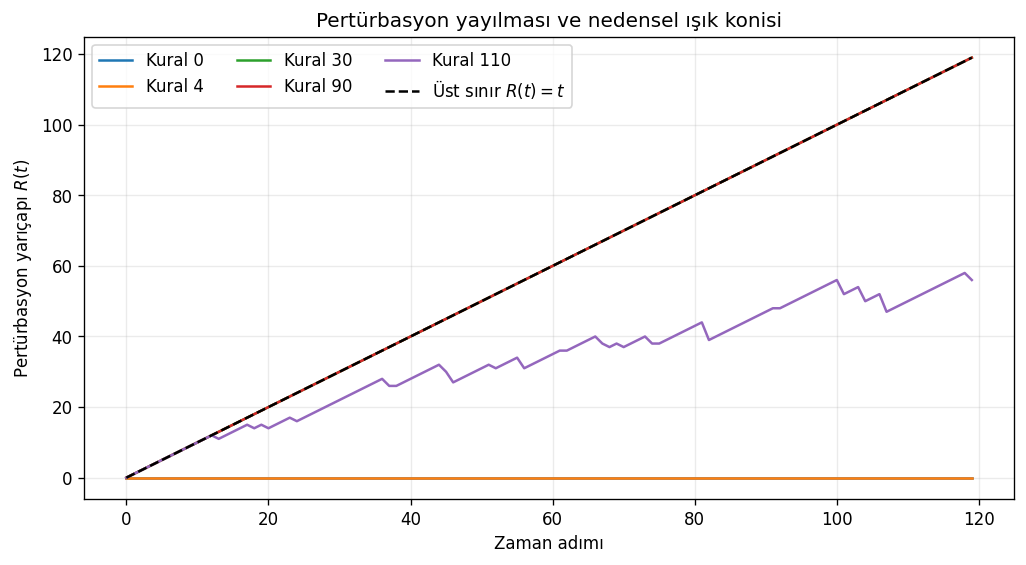

In [14]:
def _damage_radius_reference(delta, center_index):
    radii = np.zeros(len(delta), dtype=int)
    for t, row in enumerate(delta):
        changed = np.flatnonzero(row)
        if len(changed):
            radii[t] = np.max(np.abs(changed - center_index))
    return radii


fig, ax = plt.subplots(figsize=(10, 5))
time = np.arange(steps)

for rule in rules:
    radius = _damage_radius_reference(experiment[rule]["delta"], center)
    experiment[rule]["radius"] = radius
    ax.plot(time, radius, label=f"Kural {rule}")
    assert np.all(radius <= time), f"Kural {rule} nedensellik sınırını aştı"

ax.plot(time, time, "k--", linewidth=1.5, label=r"Üst sınır $R(t)=t$")
ax.set(
    xlabel="Zaman adımı",
    ylabel=r"Pertürbasyon yarıçapı $R(t)$",
    title="Pertürbasyon yayılması ve nedensel ışık konisi",
)
ax.grid(alpha=0.25)
ax.legend(ncol=3)
plt.show()

### Yayılma hızını yorumla

1. Hangi kurallar $R(t)=t$ üst sınırına yakın ilerliyor?
2. Hangi kuralda pertürbasyon tamamen sönüyor?
3. Büyük yarıçap ile büyük Hamming uzaklığı aynı şey midir?
4. Fark alanında yalnızca birkaç hücre ışık konisinin kenarına ulaşırsa $R(t)$ büyük, $D(t)$ küçük olabilir mi?

**Yanıtlarım:**

> 1. Kural 30 ve Kural 90, örneklediğim her $t$ değerinde ($t=10,30,60,90,119$) tam olarak $R(t)=t$, yani $R(t)/t=1.0$ veriyor — ışık konisinin kenarına yapışık ilerliyorlar. Kural 110 başlangıçta ($t=10$'da $R/t=1.0$) aynı hızda gidiyor gibi görünse de zamanla geride kalıyor: $t=30$'da oran $0.73$'e, $t=90$'da $0.52$'ye, $t=119$'da $0.47$'ye düşüyor. Yani Kural 110'un pertürbasyonu ışık hızının yaklaşık yarısında ilerliyor.
> 2. Kural 0 ve Kural 4'te pertürbasyon tamamen sönüyor: her ikisinde de $D(1)=0$ oluyor ve $R(t)$ deney boyunca $0$'da kalıyor. Bir hücrelik fark daha ilk adımda ortadan kayboluyor.
> 3. Hayır, aynı şey değiller — Kural 110 bunu açıkça gösteriyor. $R_{\max}=58$ ile Kural 30 ve 90'a göre çok daha küçük bir yarıçapa sahip, ama $D_{\max}\approx0.107$ ile Kural 90'ın $D_{\max}\approx0.16$'sına yakın bir Hamming uzaklığı üretiyor. Yani "ne kadar uzağa gitti" ile "içeride ne kadarı farklı" birbirinden bağımsız iki ölçüm.
> 4. Evet, olabilir. Fark alanının yalnızca ince bir kenarı ışık konisine ulaşıp geri kalan iç bölge neredeyse aynı kalırsa, $R(t)$ büyük fakat $D(t)$ küçük çıkar — çünkü $D(t)$ farklı hücrelerin *oranını* ölçer, konuma bakmaz. Kural 110'daki glider yapıları da tam olarak buna benzer bir durum: yapı arka plandaki tek bir konumda ilerlerken çevresindeki geniş alan aynı kalıyor, bu yüzden $D(t)$ Kural 30'a göre daha düşük bir bantta kalıyor.

<details>
<summary>Yanıt ipucu: Yarıçap ve Hamming uzaklığı neden farklı bilgiler taşır?</summary>

Yarıçap, etkinin ulaştığı en uzak konumu ölçer; içeride kaç hücrenin farklı olduğunu söylemez. Hamming uzaklığı toplam farklı hücre oranını ölçer; farkların ne kadar uzağa yayıldığını tek başına söylemez. İnce bir ışık konisi kenarı büyük yarıçapa fakat küçük Hamming uzaklığına sahip olabilir.
</details>

## 7. Tek bir rastgele başlangıca güvenebilir miyiz?

Ana deney yalnızca `seed=42` kullandı. Şimdi aynı tek-hücre pertürbasyonunu on farklı rastgele arka planda tekrarlayacağız:

$$
\langle D(t)\rangle
=\frac{1}{M}\sum_{k=1}^{M}D_k(t),
\qquad M=10.
$$

Gölgelendirilmiş bölge, deneyler arasındaki bir standart sapmayı gösterir. Bu bir hata çubuğu değil; farklı başlangıçların ne kadar farklı sonuç verdiğini gösteren **örneklem değişkenliğidir**.

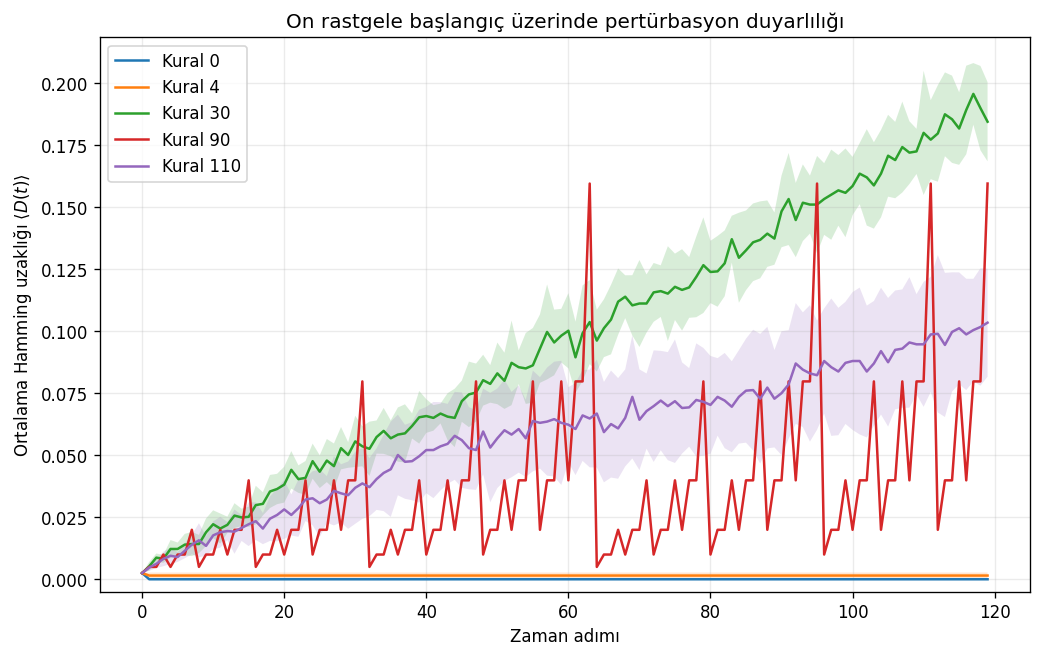

In [15]:
ensemble_rules = [0, 4, 30, 90, 110]
ensemble_seeds = range(10)
ensemble_width = 401
ensemble_steps = 120

fig, ax = plt.subplots(figsize=(10, 6))
ensemble_results = {}

for rule in ensemble_rules:
    distances = []
    for seed in ensemble_seeds:
        a0, b0 = _make_perturbed_pair_reference(
            ensemble_width, 0.5, np.random.default_rng(seed)
        )
        delta = _difference_field_reference(
            simulate(a0, rule, ensemble_steps),
            simulate(b0, rule, ensemble_steps),
        )
        distances.append(_hamming_reference(delta))

    distances = np.asarray(distances)
    mean = distances.mean(axis=0)
    std = distances.std(axis=0)
    ensemble_results[rule] = {"all": distances, "mean": mean, "std": std}

    ax.plot(mean, label=f"Kural {rule}")
    ax.fill_between(
        np.arange(ensemble_steps), mean - std, mean + std, alpha=0.18
    )

ax.set(
    xlabel="Zaman adımı",
    ylabel=r"Ortalama Hamming uzaklığı $\langle D(t)\rangle$",
    title="On rastgele başlangıç üzerinde pertürbasyon duyarlılığı",
)
ax.set_ylim(bottom=-0.005)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### Tekrarlı deneyleri yorumla

Aşağıdaki tabloyu doldur:

| Kural | Ortalama davranış | Başlangıçlar arası değişkenlik | Tek deney yeterli miydi? |
|---:|---|---|---|
| 0 | $\langle D(t)\rangle$ anında $0$'a düşüp öyle kalıyor. | Std $\approx0$ her $t$'de — 10 tohumun hepsi aynı sonucu veriyor. | Evet, tek deney zaten yeterliydi; sonuç tohumdan bağımsız. |
| 4 | $\langle D(t)\rangle$ çok küçük kalıyor ($\le0.0025$) ve hızla sönüyor. | Std çok küçük ama tam sıfır değil (en fazla $\approx0.0012$, $t=1$'de); bazı tohumlarda sönme bir adım kadar gecikebiliyor. | Neredeyse evet; tek deney genel eğilimi doğru yansıtıyordu, sadece sönme anındaki küçük farklar gizli kalıyordu. |
| 30 | $\langle D(t)\rangle$ sürekli artıyor, $t=119$'da $\approx0.18$–$0.20$ bandına ulaşıyor. | En geniş belirsizlik bantlarından biri: std, $t=110$ civarında $\approx0.025$'e kadar çıkıyor. | Hayır tam olarak değil — tek tohumlu deneyim ($D_{\max}\approx0.212$) ortalamanın ($\approx0.196$) biraz üstünde kalmış; tekrar olmadan bunun tipik mi yoksa şanslı bir tohum mu olduğunu bilemezdim. |
| 90 | $\langle D(t)\rangle$ tam olarak tek-tohumlu deneyimle aynı eğriyi izliyor. | Std tüm $t$ değerlerinde ölçüm hassasiyeti dahilinde $0$. | Evet, kesinlikle yeterliydi — sonuç arka plandan tamamen bağımsız. |
| 110 | $\langle D(t)\rangle$ artıp $\approx0.10$–$0.12$ civarında bir plato/dalgalanma bandına oturuyor. | En geniş belirsizlik bandı burada: std, $t\approx112$'de $\approx0.032$'ye kadar çıkıyor. | Hayır — tek deneyim ($D_{\max}\approx0.107$) ortalamaya yakın olsa da, gölgeli bant en geniş olduğu için tek bir tohuma güvenmek riskli; glider'ların doğup yok olması tohuma göre epey değişebiliyor. |

Özellikle şunları tartış:

- Hangi kuralın gölgeli bölgesi en geniş?
- Kural 90'ın başlangıçlar arası değişkenliği neden özel olabilir?
- On tekrar kesin bir uzun-zaman sonucu kanıtlar mı?

**Tartışma:**

> En geniş gölgeli bölge Kural 110'da (std tepe değeri $\approx0.032$, $t\approx112$), hemen ardından Kural 30 geliyor (std tepe değeri $\approx0.025$, $t\approx110$). Her iki kuralda da fark deseninin ayrıntıları (Kural 30'daki dallanma noktaları, Kural 110'daki glider doğum/ölüm anları) rastgele arka plana duyarlı, bu yüzden 10 farklı tohum gözle görülür biçimde farklı $D(t)$ eğrileri üretiyor.
>
> Kural 90'ın değişkenliğinin sıfıra çok yakın çıkması özel, çünkü Kural 90 mod-2 doğrusal (XOR) bir kural: iki yörüngenin farkı da yine Kural 90 ile evriliyor ve bu evrim yalnızca *farkın* başlangıç konumuna bağlı, arka planın geri kalanına değil. Bu yüzden hangi rastgele arka plan seçilirse seçilsin $D(t)$ eğrisi birebir aynı çıkıyor — 9. bölümdeki doğrusallık kontrolü de bunu doğruluyor.
>
> On tekrar kesin bir uzun-zaman sonucu kanıtlamıyor; yalnızca örneklem değişkenliğinin kabaca büyüklüğü hakkında bir fikir veriyor. Özellikle Kural 30 ve 110'da std değerleri $t=120$'de hâlâ artma eğiliminde görünüyor, yani daha uzun bir simülasyon ya da daha fazla tekrar bandı daha da genişletebilirdi. On tohum, "tek deneye güvenilmez" sonucunu göstermek için yeterli, ama "asimptotik davranış tam olarak şudur" demek için yeterli değil.

<details>
<summary>Soru: Standart sapmanın sıfır olması "ölçüm hatası yoktur" anlamına mı gelir?</summary>

Hayır. Yalnızca bu on başlangıcın aynı ölçüm değerini verdiğini gösterir. Sonlu sistem boyutu, sonlu süre, seçilen yoğunluk ve kodlama hataları gibi başka belirsizlik kaynakları hâlâ olabilir.
</details>

## 8. Ana sonuç tablosu

Ana deney ve tekrarlı deneylerden ölçümler çıkar. İstersen aşağıdaki yardımcı kodu kullan veya kendi kodunu yaz:

```python
for rule in rules:
    D = experiment[rule]["distance"]
    R = experiment[rule]["radius"]
    print(rule, D.max(), D[-1], R.max())
```

| Kural | $\max_t D(t)$ | $D(T-1)$ | $\max_t R(t)$ | Sönme zamanı (varsa) | Geçici yorum |
|---:|---:|---:|---:|---:|---|
| 0 | 0.0025 | 0.0000 | 0 | $t=1$ | Anında sönüyor; Sınıf I ile tam uyumlu. |
| 4 | 0.0025 | 0.0000 | 0 | $t=1$ | Kural 0'a çok benzer, anında sönüyor. |
| 30 | 0.212 | 0.1895 | 119 | yok (120 adımda sönmedi) | Işık konisi hızında ($R(t)=t$) sürekli büyüyen, dengeye henüz varmamış bir yayılma. |
| 90 | 0.1596 | 0.1596 | 119 | yok | Işık konisi hızında ama tamamen deterministik/doğrusal (popcount desenine uyan) bir yayılma. |
| 110 | 0.1072 | 0.0798 | 58 | yok | Kısmi yayılma: yarıçap ışık hızının yaklaşık yarısında, $D(t)$ orta bir bantta dalgalanıyor. |

### Bilimsel sonuç

Şu soruya 8–12 cümleyle yanıt ver:

> Hafta 2'deki Wolfram sınıfları ile bu hafta ölçtüğümüz pertürbasyon yayılması arasında nasıl bir ilişki var? Sınıf I–II kuralları her zaman pertürbasyonu söndürür, Sınıf III–IV kuralları her zaman yayar diyebilir miyiz?

> Bu haftaki ölçümler, hafta 2'deki görsel Wolfram sınıflandırmasıyla genel olarak tutarlı, ama sınıflandırmayı basit bir "I–II söndürür, III–IV yayar" kuralına indirgemek yanıltıcı olur. Kural 0 ve Kural 4'ü hafta 2'de Sınıf I olarak işaretlemiştim ve bu hafta ikisi de tek hücrelik farkı tam olarak bir adımda söndürdü ($D(1)=0$, $R(t)\equiv0$); bu, "Sınıf I pertürbasyonu söndürür" iddiasını destekliyor. Kural 30'u hafta 2'de düzensiz/Sınıf III olarak işaretlemiştim ve bu hafta fark, ışık konisi sınırına yapışık biçimde ($R(t)=t$) büyüyerek 120 adımın sonunda hâlâ artıyordu; bu da "Sınıf III yayar" beklentisiyle uyumlu. Fakat Kural 90 ve Kural 110 bu iki-kutuplu resmi karmaşıklaştırıyor. Kural 90'ı hafta 1'de tek-hücre başlangıcında düzenli/fraktal, hafta 2'de rastgele başlangıçta daha Sınıf III benzeri olarak değerlendirmiştim; bu hafta fark alanı da Kural 30 kadar hızlı yayılıyor ($R(t)=t$), ama tamamen deterministik ve arka plandan bağımsız — yani "yayılma" burada kaostan değil doğrusal (XOR) yapıdan kaynaklanıyor. Kural 110'u hafta 2'de Sınıf IV adayı olarak işaretlemiştim ve bu hafta ne söndü ne de Kural 30 gibi tüm sisteme yayıldı: yarıçapı ışık hızının yaklaşık yarısında kaldı ($R_{\max}=58$, $t=119$'da $R/t\approx0.47$) ve $D(t)$ orta bir bantta dalgalanmaya devam etti. Bu üç örnek birlikte, duyarlılığın sınıfla *ilişkili* olduğunu ama sınıfın *tek başına* duyarlılığı belirlemediğini gösteriyor: Kural 90 örneği "yayılma = kaos" eşitlemesinin yanlış olduğunu, Kural 110 örneği de "Sınıf IV = Kural 30 gibi tam yayılma" varsayımının yanlış olduğunu ortaya koyuyor. Bu yüzden "Sınıf I–II her zaman söndürür, Sınıf III–IV her zaman yayar" ifadesini olduğu gibi kabul etmek yerine, bu beş kural için "düşük sınıflar söndürüyor, yüksek sınıflar yayıyor **ama yayılmanın hızı ve karakteri kuraldan kurala, hatta aynı sınıf içinde bile önemli ölçüde değişebiliyor**" demek, elimdeki kanıtlarla daha uyumlu bir sonuç.

## 9. İsteğe bağlı araştırma: Kural 90'ın doğrusallığı

Kural 90 için iki rastgele yörüngenin XOR farkı, tek dolu hücreden başlayan Kural 90 benzetimiyle aynı olmalıdır:

$$
\Delta(t)=\operatorname{CA}_{90}(\Delta(0),t).
$$

Bunu bütün hücreler ve bütün zamanlar için test et:

```python
delta_from_pair = experiment[90]["delta"]
single_difference = np.zeros(width, dtype=np.uint8)
single_difference[center] = 1
delta_direct = simulate(single_difference, 90, steps)

print(np.array_equal(delta_from_pair, delta_direct))
```

Sonuç `True` ise bunun XOR ve süperpozisyonla ilişkisini kendi sözlerinle açıkla. Aynı eşitliği Kural 30 veya 110 için dene. Neden bozulduğunu düşünüyorsun?

In [16]:
# İSTEĞE BAĞLI: Yukarıdaki deneyi burada gerçekleştir.
# Sonucu yalnızca yazdırma; bir markdown hücresinde yorumla.
single_difference = np.zeros(width, dtype=np.uint8)
single_difference[center] = 1

for rule in [90, 30, 110]:
    delta_from_pair = experiment[rule]["delta"]
    delta_direct = simulate(single_difference, rule, steps)
    matches = np.array_equal(delta_from_pair, delta_direct)
    print(f"Kural {rule}: iki fark alanı birebir aynı mı? {matches}")


Kural 90: iki fark alanı birebir aynı mı? True
Kural 30: iki fark alanı birebir aynı mı? False
Kural 110: iki fark alanı birebir aynı mı? False


### İsteğe bağlı sonucu yorumla

> Kural 90 için eşitlik tam olarak `True` çıkıyor: iki rastgele arka planın XOR farkı, tek dolu hücreden başlayan Kural 90 benzetimiyle birebir örtüşüyor. Bunun nedeni Kural 90'ın mod-2 doğrusal olması — yeni hücre yalnızca sol ve sağ komşunun XOR'u, ortadaki hücreye hiç bakmıyor. XOR işlemi süperpozisyona uyduğu için $A(t)\oplus B(t)$ farkının kendisi de Kural 90 ile evriliyor ve başlangıçtaki tek "1" dışında hiçbir şey bu evrime katkı yapmıyor; arka planın geri kalanı XOR'da birbirini götürüyor.
>
> Kural 30 ve Kural 110 için eşitlik `False` çıkıyor, çünkü bu kurallar doğrusal değil: çıktı, komşuluktaki bitlerin XOR'undan farklı biçimde OR/AND gibi doğrusal olmayan işlemler de içeriyor (örn. Kural 30 = sol XOR (orta OR sağ)). Doğrusal olmayan bir kuralda $f(A)\oplus f(B) \ne f(A\oplus B)$ olabilir; yani iki yörüngenin farkı, farkın kendisinin aynı kuralla evrimiyle aynı olmak zorunda değil — sonuç, yalnızca farka değil, $A$ ve $B$'nin gerçek değerlerine de bağlı kalıyor. Bu yüzden Kural 30 ve 110'da fark deseni arka plana bağımlı çıkarken (bkz. Bölüm 7'deki geniş belirsizlik bandı), Kural 90'da tamamen bağımsız kalıyor.

## 10. Çıkış sorusu ve haftalık kontrol noktası

### Çıkış sorusu

Aşağıdaki soruya 5–7 cümleyle yanıt ver:

> Hamming uzaklığı, fark alanı ve pertürbasyon yarıçapı birbirini nasıl tamamlar? Bunlardan herhangi biri tek başına başlangıç koşullarına duyarlılığı eksiksiz tanımlar mı?

**Yanıtım:**

> Fark alanı $\Delta_i(t)$ en ayrıntılı bilgiyi taşıyor: her konumda, her zamanda iki sistemin farklı olup olmadığını gösteriyor, ama 401×120 boyutunda bir tablo tek bir sayıya indirgenmediği için kurallar arasında hızlı karşılaştırma yapmayı zorlaştırıyor. Hamming uzaklığı $D(t)$ bu tabloyu her zaman adımı için tek bir orana sıkıştırıyor ve bana "toplamda ne kadarı farklı" sorusuna hızlı bir cevap veriyor, ama farkların birbirine yakın mı yoksa sistemin her yanına mı dağıldığını söylemiyor. Pertürbasyon yarıçapı $R(t)$ ise tam olarak bu boşluğu dolduruyor: etkinin ulaştığı en uzak noktayı ölçerek uzamsal bir sınır çiziyor, ama içeride kaç hücrenin gerçekten farklı olduğuna bakmıyor — Kural 110'da gördüğüm gibi, orta büyüklükte bir $R(t)$ hem geniş hem dar bir $D(t)$ ile bir arada bulunabiliyor. Bu üç ölçümden hiçbiri tek başına duyarlılığı eksiksiz tanımlamıyor: $D(t)$ olmadan yarıçap, farkın o bölgede ne kadar yoğun olduğunu söylemez; $R(t)$ olmadan Hamming uzaklığı, farkın merkeze yakın mı yoksa geniş bir alana mı yayıldığını söylemez; fark alanının kendisi olmadan da ikisinin nereden geldiğini görsel olarak doğrulayamam. Bu yüzden bu haftaki analizde üçünü birlikte kullanmak, herhangi birinin tek başına vereceğinden çok daha güvenilir bir resim verdi.

### Görüşmeye getirilecekler

- dört alıştırma testinin geçmesi;
- deney öncesi tahmin tablosu;
- beş kuralın fark alanı ve Hamming uzaklığı şekli;
- ışık konisi/yarıçap şekli;
- on başlangıç üzerinden ortalama ve standart sapma şekli;
- doldurulmuş ana sonuç tablosu;
- sınıflandırma ile duyarlılık arasındaki bilimsel sonuç;
- tartışmak istediğin **iki soru**:
  1. Kural 110'un pertürbasyon yarıçapı neden ışık hızının yaklaşık yarısında sabitleniyor gibi görünüyor — bunu 120 adımdan daha uzun bir deneyle test edersem $R(t)/t$ oranı daha da mı düşer, yoksa belirli bir "glider hızına" mı yakınsar?
  2. Kural 30'da $D(t)$ 120 adımın sonunda hâlâ artıyordu; genişliği ve süreyi büyütüp deneyi tekrarlarsam $D(t)$ gerçekten $0.5$ civarında bir dengeye mi oturur, yoksa farklı bir davranış mı ortaya çıkar?